# 💰 Sales Prediction Using Python
### OIBSIP Internship – Task 5
**Author:** Youssef Hatem Mohamed Bahig  
**Program:** AICTE Oasis Infobyte Internship  

---

## 📌 Objective
Build a machine learning model that predicts **how much of a product people will buy** based on advertising spend across different platforms:
- 📺 **TV** Advertising Budget
- 📻 **Radio** Advertising Budget
- 📰 **Newspaper** Advertising Budget

---

## Step 1 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2 — Load the Dataset

In [4]:
df = pd.read_csv('Advertising.csv')

print('✅ Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head(10)

✅ Dataset loaded successfully!
Shape: (200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


## Step 3 — Exploratory Data Analysis (EDA)

In [5]:
# Dataset Info
print('📋 Dataset Info:')
df.info()

📋 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
# Basic Statistics
print('📈 Statistical Summary:')
df.describe()

📈 Statistical Summary:


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
# Missing values check
print('❓ Missing Values:')
print(df.isnull().sum())

print('\n📊 Correlation with Sales:')
print(df.corr()['Sales'].sort_values(ascending=False))

❓ Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

📊 Correlation with Sales:
Sales         1.000000
TV            0.782224
Radio         0.576223
Newspaper     0.228299
Unnamed: 0   -0.051616
Name: Sales, dtype: float64


## Step 4 — Visualizations

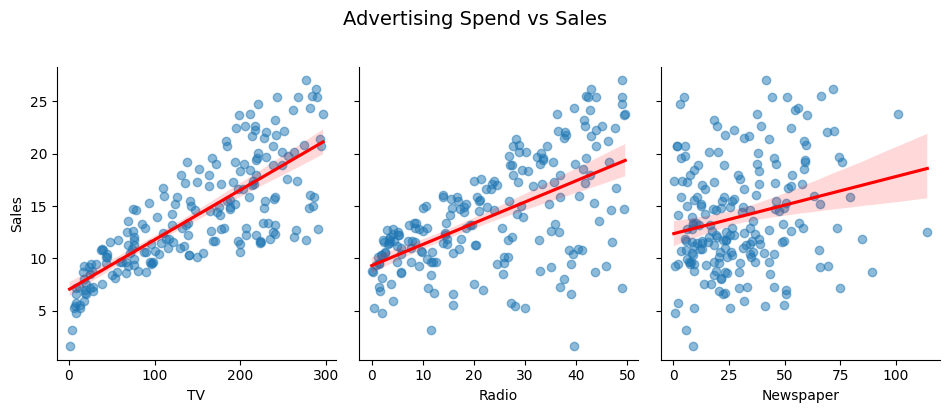

In [8]:
# 4a. Pair Plot
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales',
             height=4, aspect=0.8, kind='reg',
             plot_kws={'line_kws': {'color': 'red'}, 'scatter_kws': {'alpha': 0.5}})
plt.suptitle('Advertising Spend vs Sales', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

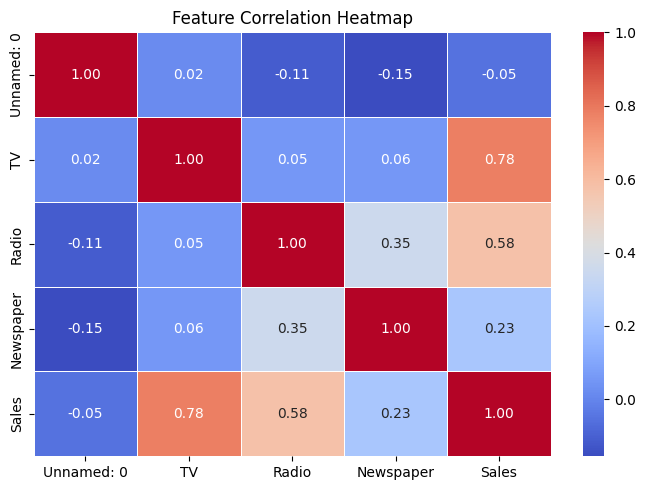

In [9]:
# 4b. Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

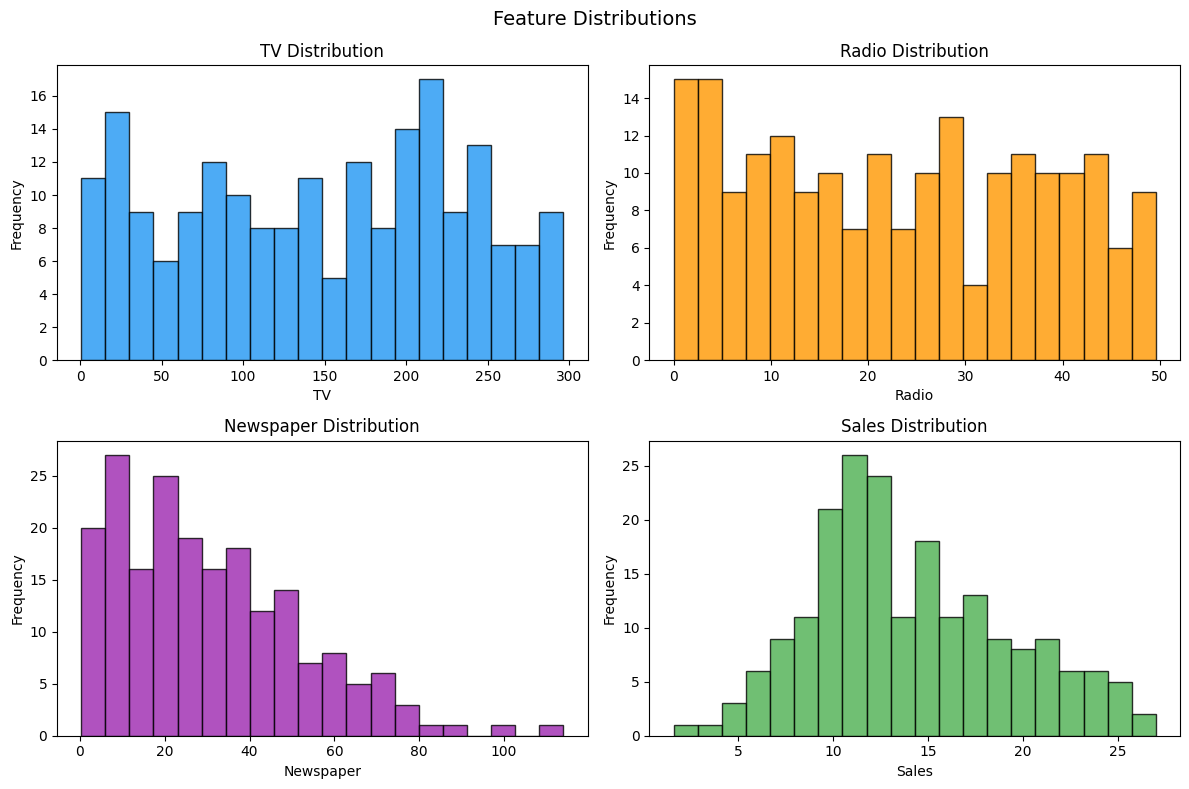

In [10]:
# 4c. Distribution of each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['TV', 'Radio', 'Newspaper', 'Sales']
colors   = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50']

for ax, feat, color in zip(axes.flatten(), features, colors):
    ax.hist(df[feat], bins=20, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(f'{feat} Distribution')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

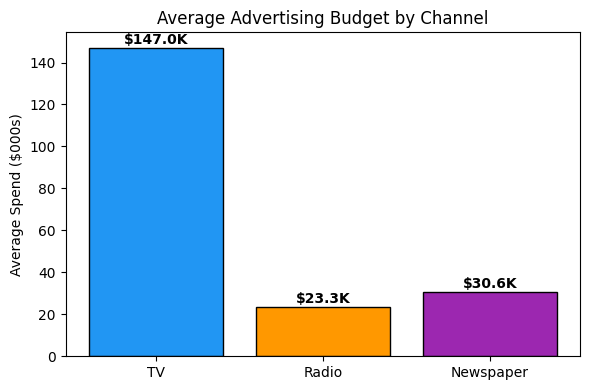

In [11]:
# 4d. Ad spend budget breakdown (mean)
plt.figure(figsize=(6, 4))
means = df[['TV', 'Radio', 'Newspaper']].mean()
bars = plt.bar(means.index, means.values,
               color=['#2196F3', '#FF9800', '#9C27B0'], edgecolor='black')
plt.title('Average Advertising Budget by Channel')
plt.ylabel('Average Spend ($000s)')

for bar, val in zip(bars, means.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:.1f}K', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 5 — Preprocessing

In [12]:
# Features and Target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'📦 Training samples : {X_train.shape[0]}')
print(f'📦 Testing  samples : {X_test.shape[0]}')
print(f'📐 Features         : {X_train.shape[1]} (TV, Radio, Newspaper)')

📦 Training samples : 160
📦 Testing  samples : 40
📐 Features         : 3 (TV, Radio, Newspaper)


## Step 6 — Train & Evaluate Models

In [13]:
models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge Regression'    : Ridge(alpha=1.0),
    'Decision Tree'       : DecisionTreeRegressor(random_state=42),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    print('=' * 55)
    print(f'🤖 {name}')
    print(f'   MAE  : {mae:.4f}')
    print(f'   RMSE : {rmse:.4f}')
    print(f'   R²   : {r2:.4f}')

🤖 Linear Regression
   MAE  : 1.4608
   RMSE : 1.7816
   R²   : 0.8994
🤖 Ridge Regression
   MAE  : 1.4644
   RMSE : 1.7874
   R²   : 0.8988
🤖 Decision Tree
   MAE  : 0.9850
   RMSE : 1.4748
   R²   : 0.9311
🤖 Random Forest
   MAE  : 0.6201
   RMSE : 0.7687
   R²   : 0.9813


## Step 7 — Compare Model Performance

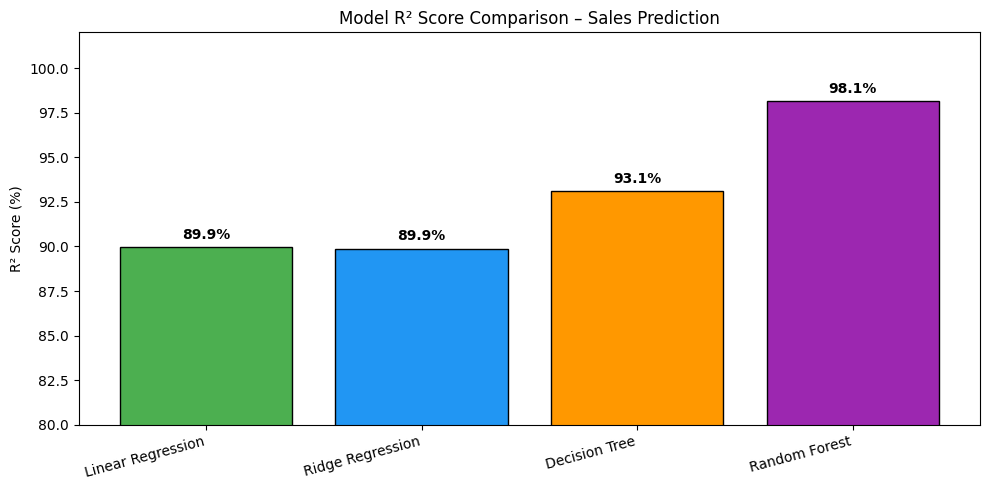


📊 Full Metrics Table:
                      MAE    RMSE      R2
Linear Regression  1.4608  1.7816  0.8994
Ridge Regression   1.4644  1.7874  0.8988
Decision Tree      0.9850  1.4748  0.9311
Random Forest      0.6201  0.7687  0.9813


In [14]:
results_df = pd.DataFrame(results).T
r2_scores  = results_df['R2'].astype(float)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    r2_scores.index,
    r2_scores.values * 100,
    color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'],
    edgecolor='black'
)
plt.ylim(80, 102)
plt.ylabel('R² Score (%)')
plt.title('Model R² Score Comparison – Sales Prediction')
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, r2_scores.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val*100:.1f}%',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n📊 Full Metrics Table:')
print(results_df.astype(float).round(4).to_string())

## Step 8 — Actual vs Predicted Plot (Best Model)

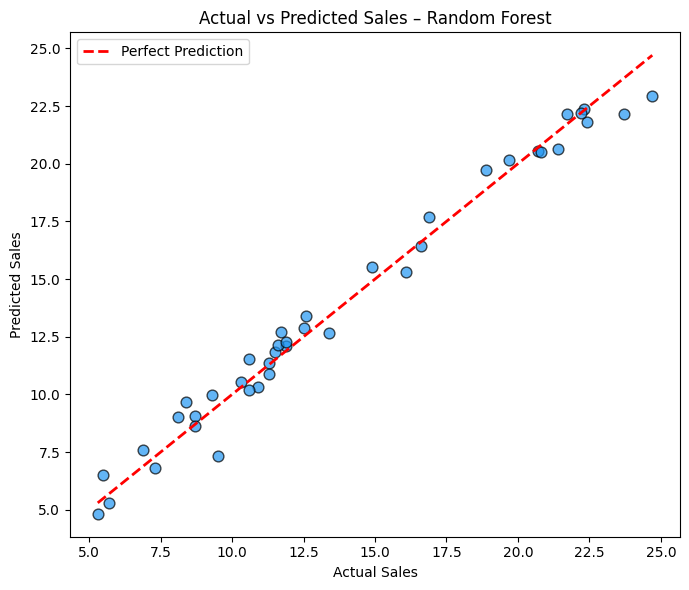


🏆 Best Model: Random Forest
   R²   : 98.13%
   RMSE : 0.7687
   MAE  : 0.6201


In [ ]:
best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = models[best_name]
best_preds = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_preds, alpha=0.7, color='#2196F3', edgecolors='black', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f'Actual vs Predicted Sales – {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\n🏆 Best Model: {best_name}')
print(f'   R²   : {results[best_name]["R2"]*100:.2f}%')
print(f'   RMSE : {results[best_name]["RMSE"]:.4f}')

print(f'   MAE  : {results[best_name]["MAE"]:.4f}')

## Step 9 — Predict a New Sample

In [16]:
# Change these advertising budgets to test your own scenarios
sample_data = [
    {'TV': 230.1, 'Radio': 37.8, 'Newspaper': 69.2},
    {'TV': 44.5,  'Radio': 39.3, 'Newspaper': 45.1},
    {'TV': 17.2,  'Radio': 45.9, 'Newspaper': 69.3},
    {'TV': 151.5, 'Radio': 41.3, 'Newspaper': 58.5},
]

print('🔮 Prediction Demo')
print('=' * 55)

for s in sample_data:
    sample_df     = pd.DataFrame([s])
    sample_scaled = scaler.transform(sample_df)
    prediction    = best_model.predict(sample_scaled)[0]

    print(f'TV: ${s["TV"]}K  |  Radio: ${s["Radio"]}K  |  Newspaper: ${s["Newspaper"]}K')
    print(f'   📈 Predicted Sales → {prediction:.2f} units')
    print('-' * 55)

🔮 Prediction Demo
TV: $230.1K  |  Radio: $37.8K  |  Newspaper: $69.2K
   📈 Predicted Sales → 21.99 units
-------------------------------------------------------
TV: $44.5K  |  Radio: $39.3K  |  Newspaper: $45.1K
   📈 Predicted Sales → 10.72 units
-------------------------------------------------------
TV: $17.2K  |  Radio: $45.9K  |  Newspaper: $69.3K
   📈 Predicted Sales → 8.71 units
-------------------------------------------------------
TV: $151.5K  |  Radio: $41.3K  |  Newspaper: $58.5K
   📈 Predicted Sales → 18.51 units
-------------------------------------------------------


## Step 10 — Final Summary

In [17]:
print('=' * 55)
print('               FINAL RESULTS SUMMARY')
print('=' * 55)
for name, metrics in results.items():
    marker = '✅ BEST' if name == best_name else '      '
    print(f'  {marker}  {name:<25} R²: {metrics["R2"]*100:.2f}%  RMSE: {metrics["RMSE"]:.4f}')
print('=' * 55)

               FINAL RESULTS SUMMARY
          Linear Regression         R²: 89.94%  RMSE: 1.7816
          Ridge Regression          R²: 89.88%  RMSE: 1.7874
          Decision Tree             R²: 93.11%  RMSE: 1.4748
  ✅ BEST  Random Forest             R²: 98.13%  RMSE: 0.7687
